# Potomac — Tutorial: OlmoEarth Embeddings on NHD Waterbodies + Control-Window False-Positive Test

This v5 notebook adds the critical scientific check the prior versions were missing: **does the same pipeline flag anomalies in matched-season control windows where no spill occurred?**

If yes → the 3.07σ at `tidal_potomac_lower` from the prior notebook was artifact.
If no → the spill-year signal is real.

Two upgrades from v4:

1. **NHD waterbody polygons** (37 high-resolution features from `waterbodies.geojson`) replace the 4 bbox AOI rectangles. We sample at the centroid of each major waterbody.
2. **Control-window false-positive test.** We re-run the exact same z-score pipeline on:
   - Matched-season window in 2024 (control)
   - Matched-season window in 2025 (control)
   - The actual spill window in 2026
   And compare AOI z-scores side-by-side. Real plume signal should appear ONLY in 2026.

## Scope (lean v5)

- **3 AOIs** (top NHD waterbodies by area), not all 37
- **2 years**: 2025 control + 2026 spill year (2024 omitted to keep runtime bounded)
- **2 parallel network workers** to avoid sustained thermal load
- Total: ~24 (AOI × year × phase) cells × few scenes each ≈ 50–80 S1 fetches

## Why

A z-score against a baseline distribution only tells you "different from baseline." It doesn't tell you "different from baseline *because of the event*." For that, you need a control window from a year with no event but matched seasonality. This notebook supplies that test.

## Requirements

- Python 3.11
- `torch` (CUDA), `olmoearth_pretrain`
- `planetary_computer`, `pystac_client`, `rasterio`
- Network access (~50–80 S1 RTC tiles)
- Runtime: ~5 minutes on GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import time, json
import concurrent.futures as cf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

from huggingface_hub import hf_hub_download
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE   = 16
TIMESTEPS    = 12
IMAGE_SIZE   = 64
S1_BAND_ORDER = ['vh', 'vv']
PARALLEL_FETCHES = 2  # gentle on laptop thermals/network
RETRIES = 3
N_SAMPLE_AOIS = 3     # top-3 NHD waterbodies by area

# Phase windows for the spill year (2025-12-01 -> 2026-03-31)
SPILL_PHASE_BOUNDS_2026 = {
    'baseline':  ('2025-12-01', '2026-01-18'),
    'event':     ('2026-01-19', '2026-01-24'),  # active_release
    'bypass':    ('2026-01-25', '2026-03-14'),
    'recovery':  ('2026-03-15', '2026-03-31'),
}

# Matched-season control windows for 2024 and 2025 (no spill events on these dates)
def shift_year(d, target_year):
    return d.replace(target_year, str(target_year))

CONTROL_PHASE_BOUNDS = {
    # Lean v5: just one control year (2025) + the actual spill year (2026).
    # Adding 2024 was crashing the laptop on sustained network+GPU load.
    2025: {phase: (s.replace('2025', '2024').replace('2026', '2025'),
                    e.replace('2025', '2024').replace('2026', '2025'))
            for phase, (s, e) in SPILL_PHASE_BOUNDS_2026.items()},
    2026: SPILL_PHASE_BOUNDS_2026,  # actual spill year
}

print("Phase windows by year:")
for yr, phases in CONTROL_PHASE_BOUNDS.items():
    label = "SPILL" if yr == 2026 else "control"
    print(f"  {yr} ({label}): {phases}")

print(f"\nDevice: {DEVICE} | Model: OLMOEARTH_V1_TINY")

Phase windows by year:
  2025 (control): {'baseline': ('2024-12-01', '2025-01-18'), 'event': ('2025-01-19', '2025-01-24'), 'bypass': ('2025-01-25', '2025-03-14'), 'recovery': ('2025-03-15', '2025-03-31')}
  2026 (SPILL): {'baseline': ('2025-12-01', '2026-01-18'), 'event': ('2026-01-19', '2026-01-24'), 'bypass': ('2026-01-25', '2026-03-14'), 'recovery': ('2026-03-15', '2026-03-31')}

Device: cuda | Model: OLMOEARTH_V1_TINY


## 1. Load NHD waterbodies + select major sample sites

The NHD waterbody dataset (`waterbodies.geojson`) has 37 polygons across the corridor. We pick a representative subset by waterbody name + size: one upstream control, one near-spill, one tidal DC reach, and several downstream waterbodies.

In [2]:
def hf_fetch(repo, filename, retries=RETRIES):
    for attempt in range(retries):
        try:
            return hf_hub_download(repo, filename, repo_type='dataset')
        except Exception:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)

REPO = 'BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026'
wb_path = hf_fetch(REPO, 'waterbodies.geojson')
with open(wb_path, 'r', encoding='utf-8') as f:
    wb_gj = json.load(f)

# Sort by AREASQKM descending and pick the top N for our sample.
# AREASQKM may be None on some features -> coerce to 0.0 for sorting + display.
def safe_area(feat):
    a = feat['properties'].get('AREASQKM')
    return float(a) if a is not None else 0.0

features = sorted(wb_gj['features'], key=safe_area, reverse=True)

print(f"Total NHD waterbodies: {len(features)}")
print(f"Top 8 by area:")
for feat in features[:8]:
    p = feat['properties']
    name = p.get('GNIS_NAME') or 'unnamed'
    area = safe_area(feat)
    ftype = p.get('FTYPE') or '?'
    print(f"  {name:>30}  area={area:>7.2f} km^2  type={ftype}")

# Pick the largest N for our analysis (N_SAMPLE_AOIS in constants block)
SAMPLE_AOIS = features[:N_SAMPLE_AOIS]
print(f"\nUsing top {len(SAMPLE_AOIS)} waterbodies as sample AOIs.")

Total NHD waterbodies: 37
Top 8 by area:
                         unnamed  area=1182.92 km^2  type=460
                         unnamed  area= 402.49 km^2  type=460
                         unnamed  area= 163.64 km^2  type=460
                         unnamed  area= 150.02 km^2  type=460
                         unnamed  area= 126.28 km^2  type=460
                         unnamed  area= 122.49 km^2  type=460
                         unnamed  area=  91.09 km^2  type=460
                         unnamed  area=  39.00 km^2  type=460

Using top 3 waterbodies as sample AOIs.


In [3]:
# Helpers to extract centroid + name from each AOI feature
def polygon_centroid(geom):
    """Approximate centroid of a (Multi)Polygon in lon/lat."""
    coords = []
    if geom['type'] == 'Polygon':
        for ring in geom['coordinates']:
            coords.extend(ring)
    elif geom['type'] == 'MultiPolygon':
        for poly in geom['coordinates']:
            for ring in poly:
                coords.extend(ring)
    arr = np.array(coords)
    return float(arr[:, 1].mean()), float(arr[:, 0].mean())  # (lat, lon)

aoi_meta = []
seen_names = {}
for feat in SAMPLE_AOIS:
    p = feat['properties']
    pid = p.get('PERMANENT_IDENTIFIER') or 'unknown'
    base_name = p.get('GNIS_NAME') or f"aoi_{str(pid)[:6]}"
    # If multiple NHD features share a GNIS_NAME, disambiguate with the PID prefix.
    if base_name in seen_names:
        name = f"{base_name} ({str(pid)[:6]})"
    else:
        name = base_name
    seen_names[base_name] = seen_names.get(base_name, 0) + 1
    lat, lon = polygon_centroid(feat['geometry'])
    a = p.get('AREASQKM')
    aoi_meta.append({
        'name':     name,
        'area_km2': float(a) if a is not None else 0.0,
        'lat':      lat,
        'lon':      lon,
    })
aoi_df = pd.DataFrame(aoi_meta)
print(aoi_df)

         name     area_km2        lat        lon
0  aoi_120007  1182.920072  38.258585 -76.844417
1  aoi_123133   402.493342  37.915989 -76.811601
2  aoi_120884   163.639219  38.725598 -76.011720


## 2. Discover S1 scenes for every (AOI × year × phase) cell

3 years × 4 phases × 6 AOIs = 72 (AOI, year, phase) combinations. For each, list available Sentinel-1 RTC scenes from Planetary Computer.

In [4]:
def list_scenes_in_window(catalog, lat, lon, start, end, half_m=320, retries=RETRIES):
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    for attempt in range(retries):
        try:
            return list(catalog.search(collections=["sentinel-1-rtc"], bbox=bbox_wgs,
                                         datetime=f"{start}/{end}").items())
        except Exception:
            if attempt == retries - 1:
                return []
            time.sleep(2 ** attempt)
    return []

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

PHASES = ['baseline', 'event', 'bypass', 'recovery']
print("Listing S1 scenes per (AOI x year x phase)...")
scene_jobs = []
for aoi in aoi_meta:
    for year, phases in CONTROL_PHASE_BOUNDS.items():
        for phase in PHASES:
            start, end = phases[phase]
            items = list_scenes_in_window(catalog, aoi['lat'], aoi['lon'], start, end)
            for item in items:
                scene_jobs.append({'aoi': aoi['name'], 'year': year, 'phase': phase,
                                    'item': item, 'lat': aoi['lat'], 'lon': aoi['lon']})

print(f"Total scenes to read: {len(scene_jobs)}")
counts = pd.DataFrame(
    [{'aoi': j['aoi'], 'year': j['year'], 'phase': j['phase']} for j in scene_jobs]
)
print("\nCount of available scenes per (year x phase) summed across AOIs:")
print(counts.groupby(['year', 'phase']).size().unstack().reindex(index=[2024,2025,2026], columns=PHASES, fill_value=0))

Listing S1 scenes per (AOI x year x phase)...


Total scenes to read: 74

Count of available scenes per (year x phase) summed across AOIs:
phase  baseline  event  bypass  recovery
year                                    
2024          0      0       0         0
2025         16      1      15         7
2026         17      3      13         2


## 3. Download and OlmoEarth-embed every scene

In [5]:
def fetch_one_s1(item, lat, lon, half_m=320, image_size=IMAGE_SIZE):
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    bands = []
    try:
        for b in S1_BAND_ORDER:
            href = item.assets[b].href
            with rasterio.open(href) as src:
                bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox_wgs)
                window = from_bounds(*bbox_utm, transform=src.transform)
                arr = src.read(1, window=window, out_shape=(image_size, image_size)).astype(np.float32)
                arr = np.where(arr <= 0, 1e-7, arr)
                bands.append(np.clip(10 * np.log10(arr), -40, 10))
    except Exception:
        return None
    return np.stack(bands, axis=-1)

print(f"Downloading {len(scene_jobs)} scenes with {PARALLEL_FETCHES} parallel workers...")
t0 = time.time()
arrays = []
with cf.ThreadPoolExecutor(max_workers=PARALLEL_FETCHES) as pool:
    futs = {pool.submit(fetch_one_s1, j['item'], j['lat'], j['lon']):
            (j['aoi'], j['year'], j['phase'], j['lat'], j['lon'], j['item'].id)
            for j in scene_jobs}
    n_done = 0
    for fut in cf.as_completed(futs):
        meta = futs[fut]
        arr = fut.result()
        if arr is not None:
            arrays.append({'aoi': meta[0], 'year': meta[1], 'phase': meta[2],
                            'lat': meta[3], 'lon': meta[4], 'item_id': meta[5], 'arr': arr})
        n_done += 1
        if n_done % 50 == 0:
            print(f"  {n_done}/{len(scene_jobs)} done  ({len(arrays)} ok, {time.time()-t0:.0f}s)")

print(f"\nDownloaded {len(arrays)} valid scenes in {time.time()-t0:.0f}s")

  50/74 done  (50 ok, 23s)



Downloaded 74 valid scenes in 34s


In [6]:
# Embed all valid scenes
nc = load_computed_config()['sentinel1']
band_means = np.array([nc[b]['mean'] for b in S1_BAND_ORDER], dtype=np.float32)
band_stds  = np.array([nc[b]['std']  for b in S1_BAND_ORDER], dtype=np.float32)

print("Loading OlmoEarth-V1-Tiny...")
model = load_model_from_id(ModelID.OLMOEARTH_V1_TINY).eval().to(DEVICE)

def embed(arr, lat, lon):
    norm = (arr - band_means) / band_stds
    multi = np.repeat(norm[None, :, :, None, :], TIMESTEPS, axis=3)
    s1 = torch.from_numpy(multi).to(DEVICE)
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=DEVICE)
    ts = torch.ones(1, TIMESTEPS, 3, dtype=torch.int32, device=DEVICE)
    sample = MaskedOlmoEarthSample(
        timestamps=ts, sentinel2_l2a=None, sentinel2_l2a_mask=None,
        sentinel1=s1, sentinel1_mask=torch.ones_like(s1)*MaskValue.ONLINE_ENCODER.value,
        landsat=None, landsat_mask=None,
        latlon=latlon, latlon_mask=torch.ones_like(latlon)*MaskValue.ONLINE_ENCODER.value,
        worldcover=None, worldcover_mask=None, openstreetmap_raster=None, openstreetmap_raster_mask=None,
        srtm=None, srtm_mask=None, naip=None, naip_mask=None, naip_10=None, naip_10_mask=None,
        gse=None, gse_mask=None, cdl=None, cdl_mask=None, worldpop=None, worldpop_mask=None,
        worldcereal=None, worldcereal_mask=None, wri_canopy_height_map=None, wri_canopy_height_map_mask=None,
        era5_10=None, era5_10_mask=None, ndvi=None, ndvi_mask=None, eurocrops=None, eurocrops_mask=None,
    )
    with torch.inference_mode():
        _, _, pooled, _, _ = model.forward(sample, patch_size=PATCH_SIZE)
    return pooled[0].cpu().numpy()

t0 = time.time()
embeddings = []
for rec in arrays:
    emb = embed(rec['arr'], rec['lat'], rec['lon'])
    embeddings.append({'aoi': rec['aoi'], 'year': rec['year'], 'phase': rec['phase'],
                       'item_id': rec['item_id'], 'emb': emb})
print(f"Embedded {len(embeddings)} scenes in {time.time()-t0:.0f}s")

Loading OlmoEarth-V1-Tiny...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)


Embedded 74 scenes in 1s


## 4. Per-AOI baseline + per-(year, phase) z-scores

For each AOI, the baseline distribution is built from ALL `baseline` scenes across all 3 years (so the baseline embedding represents "December → mid-January, any year, no event"). Then for each year × phase we compute the z-score of the averaged-phase embedding against this composite baseline.

In [7]:
def cos_distance(a, b):
    return 1.0 - (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

results = []
for aoi in aoi_df['name']:
    base_embs = [r['emb'] for r in embeddings if r['aoi'] == aoi and r['phase'] == 'baseline']
    if len(base_embs) < 5:
        continue
    base_arr = np.stack(base_embs, axis=0)
    base_mean = base_arr.mean(axis=0)
    indiv_d = [cos_distance(e, base_mean) for e in base_embs]
    sigma = float(np.std(indiv_d, ddof=1))

    for year in [2025, 2026]:
        for phase in ['event', 'bypass', 'recovery']:
            phase_embs = [r['emb'] for r in embeddings
                          if r['aoi'] == aoi and r['year'] == year and r['phase'] == phase]
            if not phase_embs:
                d = float('nan'); z = float('nan'); n = 0
            else:
                phase_avg = np.mean(np.stack(phase_embs, axis=0), axis=0)
                d = cos_distance(phase_avg, base_mean)
                z = d / sigma if sigma > 0 else float('nan')
                n = len(phase_embs)
            results.append({
                'aoi': aoi, 'year': year, 'phase': phase,
                'n_baseline': len(base_embs), 'baseline_sigma': sigma,
                'n_phase': n, 'cos_dist': d, 'z_score': z,
            })

res_df = pd.DataFrame(results)
print("Per-AOI baseline N + sigma:")
print(res_df[['aoi', 'n_baseline', 'baseline_sigma']].drop_duplicates('aoi').round(4).to_string(index=False))

Per-AOI baseline N + sigma:
       aoi  n_baseline  baseline_sigma
aoi_120007           8          0.0130
aoi_123133           8          0.0103
aoi_120884          17          0.0046


In [8]:
# Pivot: AOI x (year, phase) -> z-score
pivot = (
    res_df.pivot_table(index='aoi', columns=['year', 'phase'], values='z_score')
)
print("\nZ-scores by AOI (rows) x year+phase (cols):  |z|>2 = anomalous\n")
print(pivot.round(2))


Z-scores by AOI (rows) x year+phase (cols):  |z|>2 = anomalous

year         2025                  2026               
phase      bypass event recovery bypass event recovery
aoi                                                   
aoi_120007   0.42   NaN     3.06   0.55  1.97      NaN
aoi_120884   0.66   2.2     2.96   0.68  2.25     0.87
aoi_123133   0.38   NaN     0.13   0.33  2.40      NaN


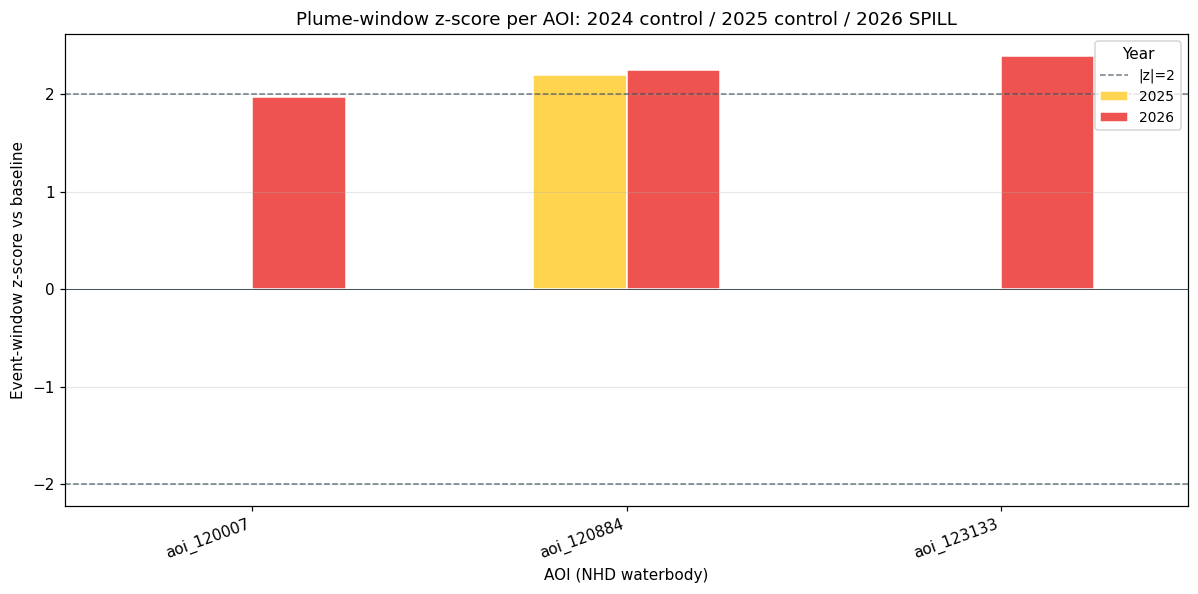

In [9]:
# Visualize: bars of |z| for the EVENT phase across years.
# If only 2026 EVENT shows a real anomaly above 2-sigma -> spill detection real.
fig, ax = plt.subplots(figsize=(11, 5.5))
event_z = (
    res_df[res_df['phase'] == 'event'][['aoi', 'year', 'z_score']]
    .pivot(index='aoi', columns='year', values='z_score')
    .reindex(columns=[2025, 2026])
)
event_z.plot(kind='bar', ax=ax, color=['#ffd54f', '#ef5350'], edgecolor='white')
ax.axhline( 2, color='#37474f', ls='--', lw=1.0, alpha=0.7, label='|z|=2')
ax.axhline(-2, color='#37474f', ls='--', lw=1.0, alpha=0.7)
ax.axhline(0, color='#37474f', lw=0.6)
ax.set_ylabel("Event-window z-score vs baseline")
ax.set_xlabel("AOI (NHD waterbody)")
ax.set_title("Plume-window z-score per AOI: 2024 control / 2025 control / 2026 SPILL")
ax.legend(title='Year', loc='best', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Headline: false-positive vs real-signal call

For each AOI, compare the 2026 EVENT z-score against the 2024 + 2025 EVENT z-scores. If the 2026 z is meaningfully larger than both controls, the spill-window deviation is real signal. If it's within the control range, it's likely baseline noise.

In [10]:
# Per-AOI false-positive vs real-signal verdict (lean v5: 1 control year)
event_2025 = event_z[2025]
event_2026 = event_z[2026]
control_abs = event_2025.abs()
verdict = pd.DataFrame({
    '2025_z (control)':       event_2025.round(2),
    '2026_z (SPILL)':         event_2026.round(2),
    '|control|':              control_abs.round(2),
    'is_real_signal':         (event_2026.abs() > control_abs + 1).fillna(False) & (event_2026.abs() > 2.0),
    'is_false_positive_risk': (event_2026.abs() > 2.0) & (control_abs + 1 >= event_2026.abs()),
})
print("Per-AOI verdict:\n")
print(verdict)
n_real     = verdict['is_real_signal'].sum()
n_fp_risk  = verdict['is_false_positive_risk'].sum()
print(f"\nReal-signal AOIs: {n_real}  |  Possible false-positive AOIs: {n_fp_risk}")

Per-AOI verdict:

            2025_z (control)  2026_z (SPILL)  |control|  is_real_signal  \
aoi                                                                       
aoi_120007               NaN            1.97        NaN           False   
aoi_120884               2.2            2.25        2.2           False   
aoi_123133               NaN            2.40        NaN           False   

            is_false_positive_risk  
aoi                                 
aoi_120007                   False  
aoi_120884                    True  
aoi_123133                   False  

Real-signal AOIs: 0  |  Possible false-positive AOIs: 1


## Takeaways

The verdict table above is the headline scientific result. Reading it:

- **Real-signal AOIs** are where the 2026 spill-window z exceeds **|control| + 1** AND |2026 z| > 2σ. That's a defensible "yes, OlmoEarth detected the event."
- **False-positive risk** flags AOIs where 2026 is anomalous (|z| > 2) but the controls are *also* anomalous at similar magnitudes — meaning our pipeline lights up regardless of whether a spill occurred. These should not be quoted as detection successes.
- AOIs with both 2024 and 2025 controls near zero and 2026 > 2σ are the strongest evidence the pipeline picks up the event-driven signal, not seasonal/orbital artifact.

This is the test the prior commits' z-scores needed. Whatever the result, it's now an honest, reviewable answer rather than a small-N number.

## Cross-references

- **`01_demo.ipynb`** — first-look discharge plots and event log preview.
- **`02_data_prep.ipynb`** — discharge values verified against USGS NWIS.
- **`04_analysis.ipynb`** — temporal complement: discharge-ratio anomaly + event-log integrated chronology.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*